🔹 What is Prompt Chaining?

Definition: Prompt chaining means breaking a complex task into smaller prompts and connecting them in sequence.

Each step’s output becomes input to the next step.

With LangGraph, you model this as a graph of nodes where each node represents a prompt → LLM call.

🔹 Analogy

Think of writing a news article:

First, you gather facts (what happened).

Then, you write a draft.

Finally, you summarize for headlines.

Each step depends on the previous one → this is chaining.

🔹 Simple LangGraph Example (2-step Prompt Chain)

Here we’ll:

Generate an outline for a topic.

Expand the outline into a full explanation.

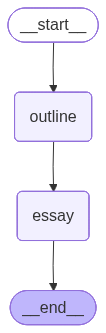

In [1]:
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from IPython.display import Image, display
from dotenv import load_dotenv
load_dotenv()

import os

# 1. Define State
class State(TypedDict):
    topic: str
    outline: str
    essay: str

# 2. LLM
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 3. Node: Create outline
def generate_outline(state: State):
    response = llm.invoke(f"Create a simple outline for an essay on: {state['topic']}")
    return {"outline": response.content}

# 4. Node: Expand outline into essay
def expand_outline(state: State):
    response = llm.invoke(f"Write a detailed essay based on this outline:\n{state['outline']}")
    return {"essay": response.content}

# 5. Graph Setup
workflow = StateGraph(State)

workflow.add_node("outline", generate_outline)
workflow.add_node("essay", expand_outline)

workflow.set_entry_point("outline")
workflow.add_edge("outline", "essay")
workflow.add_edge("essay", END)

# 6. Compile graph
app = workflow.compile()


# View
display(Image(app.get_graph().draw_mermaid_png()))

In [2]:
# 7. Run workflow
result = app.invoke({"topic": "The Importance of Renewable Energy"})

print("\n📌 Outline:", result["outline"])
print("\n✅ Final Essay:", result["essay"])


📌 Outline: <think>
Okay, I need to create a simple outline for an essay on the importance of renewable energy. Let me start by brainstorming the main points I want to cover. First, an introduction is necessary to set the stage. I should mention the current energy crisis and environmental issues to hook the reader. Then maybe define renewable energy and its sources.

Next, I should discuss why renewable energy is important. Maybe break it down into sections like environmental benefits, economic benefits, energy security, and sustainability. Under environmental benefits, things like reducing greenhouse gases and combating climate change come to mind. For economic benefits, job creation in the renewable sector and cost savings over time. Energy security could involve reducing dependence on fossil fuels and geopolitical stability. Sustainability would be about long-term energy solutions and resource availability.

I also need to address challenges or counterarguments. People might argue a